In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

#  Load the data 
df = pd.read_csv('creditcard.csv')

# Fast Preprocessing (as before)
# In Deep Learning Scaling is MANDATORY
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df = df.drop(['Time', 'Amount'], axis=1)

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [3]:
# Calculating Class Weights
# We tell the model: "If you lose one fraud, it's like you lost 500 legitimate transactions"
weights = {0: 1, 1: 500}

# Early Stopping
# Stops training if the model stops improving (save time)
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)

print("Pro tools are set!")

Pro tools are set!


In [4]:
model = Sequential([
    Dense(units=16, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(units=8, activation='relu'),
    Dropout(0.2),
    Dense(units=1, activation='sigmoid') # Exit: Possibility of fraud
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Weight training and early stopping
model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    class_weight=weights
)

Epoch 1/20
7121/7121 [==============================] - 16s 2ms/step - loss: 0.5348 - accuracy: 0.9623 - val_loss: 0.1136 - val_accuracy: 0.9838
Epoch 2/20
7121/7121 [==============================] - 15s 2ms/step - loss: 0.3371 - accuracy: 0.9825 - val_loss: 0.0550 - val_accuracy: 0.9930
Epoch 3/20
7121/7121 [==============================] - 16s 2ms/step - loss: 0.3207 - accuracy: 0.9855 - val_loss: 0.0644 - val_accuracy: 0.9927
Epoch 4/20
7121/7121 [==============================] - 16s 2ms/step - loss: 0.2805 - accuracy: 0.9792 - val_loss: 0.0672 - val_accuracy: 0.9860
Epoch 5/20
7121/7121 [==============================] - 17s 2ms/step - loss: 0.2632 - accuracy: 0.9732 - val_loss: 0.0770 - val_accuracy: 0.9765
Epoch 6/20
7121/7121 [==============================] - 17s 2ms/step - loss: 0.2377 - accuracy: 0.9717 - val_loss: 0.0704 - val_accuracy: 0.9717
Epoch 7/20
7121/7121 [==============================] - 17s 2ms/step - loss: 0.2500 - accuracy: 0.9718 - val_loss: 0.0639 - val_ac

1781/1781 [==============================] - 2s 1ms/step


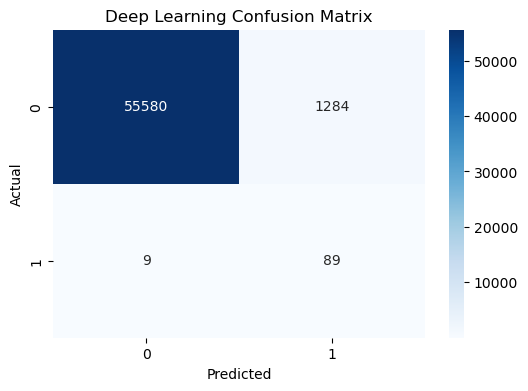

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.91      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [5]:
#  We get the predictions
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

#  Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Deep Learning Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Report
print(classification_report(y_test, y_pred))

1781/1781 [==============================] - 2s 1ms/step


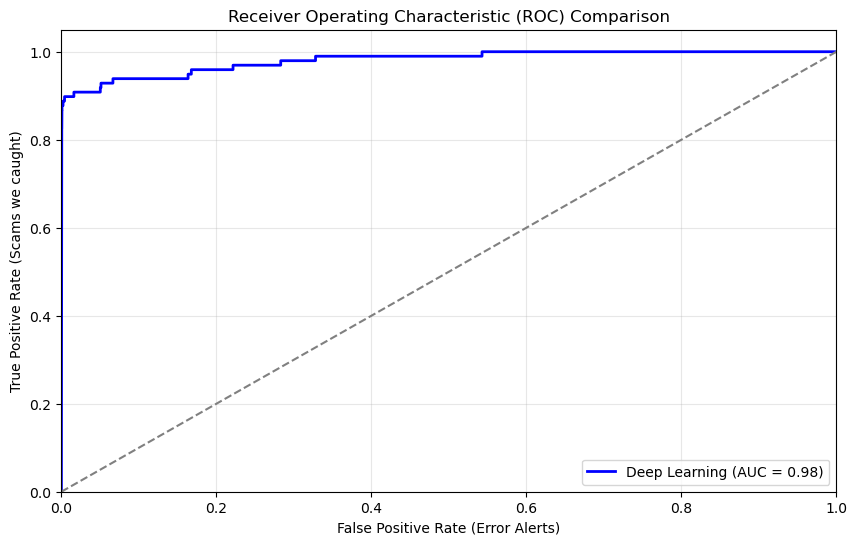

In [6]:
#  We get the probabilities from Deep Learning (you already have them)
nn_probs = model.predict(X_test).flatten()

#  We calculate the ROC curve for Deep Learning
fpr_nn, tpr_nn, _ = roc_curve(y_test, nn_probs)
roc_auc_nn = auc(fpr_nn, tpr_nn)

#  Design
plt.figure(figsize=(10, 6))
plt.plot(fpr_nn, tpr_nn, color='blue', lw=2, label=f'Deep Learning (AUC = {roc_auc_nn:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') # Diagonal (random prediction)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Error Alerts)')
plt.ylabel('True Positive Rate (Scams we caught)')
plt.title('Receiver Operating Characteristic (ROC) Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [7]:
# Use nn_probs instead of model_probabilities
thresholds = np.linspace(0, 1, 101)
profits = []

for t in thresholds:
    temp_preds = (nn_probs >= t).astype(int)

In [8]:
#  We get the probabilities from the Deep Learning model
nn_probs = model.predict(X_test).flatten()

#  We define the economic parameters (same as before for fair comparison)
cost_per_alert = 0.01 
fraud_penalty_multiplier = 1.0
thresholds = np.linspace(0, 1, 101)
profits = []

# We use y_test and the original df for the sums
quant_df = df.loc[y_test.index, ['Class', 'scaled_amount']] 

for t in thresholds:
    temp_preds = (nn_probs >= t).astype(int)
    preds_series = pd.Series(temp_preds, index=quant_df.index)
    
    # Cost of Inspections
    ops_cost = temp_preds.sum() * cost_per_alert
    
    # Profit from what we caught
    saved_amt = quant_df[(quant_df['Class'] == 1) & (preds_series == 1)]['scaled_amount'].sum()
    
    # Damage from what we lost
    missed_amt = quant_df[(quant_df['Class'] == 1) & (preds_series == 0)]['scaled_amount'].sum() * fraud_penalty_multiplier
    
    net_profit = saved_amt - ops_cost - missed_amt
    profits.append(net_profit)

#  Show Results
best_index = np.argmax(profits)
print("-" * 30)
print(f"DEEP LEARNING QUANT RESULTS")
print("-" * 30)
print(f"Best Threshold: {thresholds[best_index]:.2f}")
print(f"Max Net Profit: {profits[best_index]:.2f}€")
print("-" * 30)

1781/1781 [==============================] - 2s 1ms/step
------------------------------
DEEP LEARNING QUANT RESULTS
------------------------------
Best Threshold: 0.99
Max Net Profit: 3.83€
------------------------------
